In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import time

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"{DEVICE} is running")

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 15
NUM_CLASSES = 2

TRAIN_DIR = './dataset/train_dataset' # 400+400
TEST_DIR = './dataset/test_dataset'   # 100+100 
print(f"paths is checked")

mps is running
paths is checked


In [5]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
print(f"Images transformation has been done.")

Images transformation has been done.


In [6]:
print("\n>>> PyTorch Dataset Loading...")

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(TEST_DIR, transform=data_transforms['val'])

print(f"Class to Index: {train_dataset.class_to_idx}")


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"The size for training: {len(train_dataset)}. ")
print(f"The size for testing: {len(test_dataset)}.")


>>> PyTorch Dataset Loading...
Class to Index: {'0_ordinary': 0, '1_fake': 1}
The size for training: 800. 
The size for testing: 200.


In [7]:

class GridNet4depth(nn.Module):
    def __init__(self):
        super(GridNet4depth, self).__init__()
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # --- Block 1 (3 -> 32) ---
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # 224 -> 112
        
        # --- Block 2 (32 -> 64) ---
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # 112 -> 56
        
        # --- Block 3 (64 -> 128) ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # 56 -> 28

        # --- Block 4 (128 -> 256) ---
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        # 28 -> 14

        # --- Classifier ---
        self.fc1 = nn.Linear(256 * 14 * 14, 512) 
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2) # NUM_CLASSES

    def forward(self, x):
        # Block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        
        # Block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        
        # Block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        # Block 4 
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        
        # Flatten & FC
        x = x.view(x.size(0), -1) 
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = GridNet4depth().to(DEVICE)
print("\n>>> model is loaded in GPU")


>>> model is loaded in GPU


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(epoch_index):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    return avg_loss, acc

def validate():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(test_loader)
    acc = 100 * correct / total
    return avg_loss, acc

In [8]:

print(f"\n>>> Training: (Epochs: {EPOCHS})...")
train_losses, train_accs = [], []
val_losses, val_accs = [], []

start_time = time.time()

for epoch in range(EPOCHS):
    t_loss, t_acc = train_one_epoch(epoch)
    v_loss, v_acc = validate()
    
    train_losses.append(t_loss)
    train_accs.append(t_acc)
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.2f}%")

total_time = time.time() - start_time
print(f"\n>>> Finish. Time cost: {total_time:.2f}s")


>>> Training: (Epochs: 15)...
Epoch [1/15] Train Loss: 7.3139 Acc: 72.75% | Val Loss: 3.5086 Acc: 66.50%
Epoch [2/15] Train Loss: 1.3742 Acc: 87.38% | Val Loss: 0.2199 Acc: 94.50%
Epoch [3/15] Train Loss: 0.4881 Acc: 89.50% | Val Loss: 0.2663 Acc: 95.00%
Epoch [4/15] Train Loss: 0.2378 Acc: 90.38% | Val Loss: 0.1948 Acc: 94.50%
Epoch [5/15] Train Loss: 0.1897 Acc: 92.75% | Val Loss: 0.2966 Acc: 91.50%
Epoch [6/15] Train Loss: 0.1737 Acc: 93.00% | Val Loss: 0.1346 Acc: 95.50%
Epoch [7/15] Train Loss: 0.1233 Acc: 96.38% | Val Loss: 0.2070 Acc: 95.50%
Epoch [8/15] Train Loss: 0.1090 Acc: 96.12% | Val Loss: 0.1582 Acc: 95.00%
Epoch [9/15] Train Loss: 0.1380 Acc: 95.38% | Val Loss: 0.0949 Acc: 96.50%
Epoch [10/15] Train Loss: 0.1397 Acc: 95.12% | Val Loss: 0.1148 Acc: 96.00%
Epoch [11/15] Train Loss: 0.1011 Acc: 96.00% | Val Loss: 0.1382 Acc: 96.00%
Epoch [12/15] Train Loss: 0.1593 Acc: 93.75% | Val Loss: 0.2043 Acc: 94.00%
Epoch [13/15] Train Loss: 0.1033 Acc: 95.75% | Val Loss: 0.1217 Ac

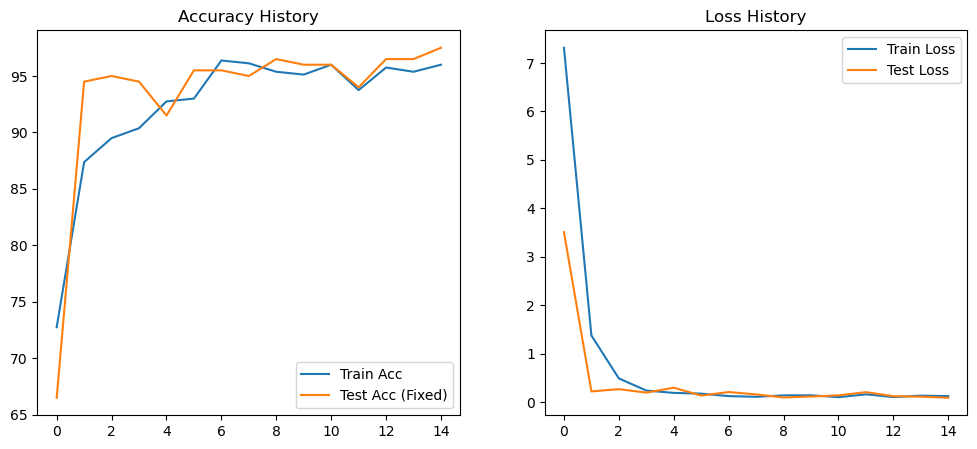

In [9]:

torch.save(model.state_dict(), '500_4depth_pytorch.pth')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Test Acc (Fixed)')
plt.title('Accuracy History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.show()